<a href="https://colab.research.google.com/github/Ninja12309/Section3_Python_Data_Processing/blob/main/NorthStar_Section3_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload datasets

In [1]:
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


# Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets

In [4]:
customers = pd.read_csv("customers.csv")

orders = pd.read_csv("orders.csv")

drivers = pd.read_csv("drivers.csv")

vehicles = pd.read_csv("vehicles.csv")

deliveries = pd.read_csv("deliveries.csv")

complaints = pd.read_csv("complaints.csv")

app_events = pd.read_csv("app_events.csv")

incidents = pd.read_csv("incidents.csv")

hubs = pd.read_csv("hubs.csv")

# Convert date columns

In [6]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"])


complaints["created_at"] = pd.to_datetime(complaints["created_at"])

app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"])

incidents["reported_at"] = pd.to_datetime(incidents["reported_at"])

vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"])

# ANALYSIS 1 — Customer segmentation by loyalty score

Purpose:
identify customer value groups

loyalty_segment
Medium    398
High      162
Low        70
Name: count, dtype: int64


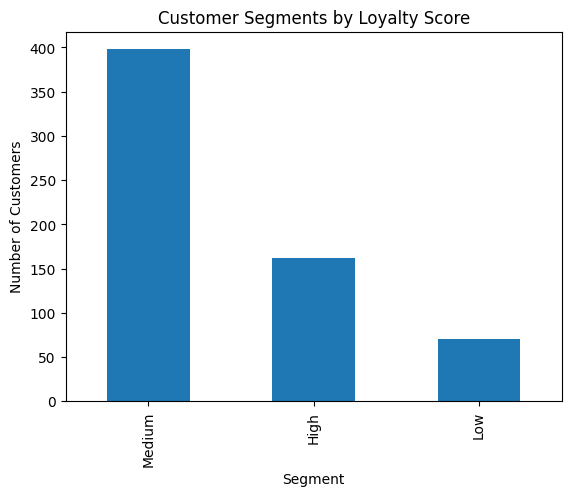

In [7]:
customers["loyalty_segment"] = pd.cut(
    customers["loyalty_score"],
    bins=[0,40,70,100],
    labels=["Low","Medium","High"]
)

segment_counts = customers["loyalty_segment"].value_counts()

print(segment_counts)

plt.figure()

segment_counts.plot(kind="bar")

plt.title("Customer Segments by Loyalty Score")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

# ANALYSIS 2 — Orders per zone

Purpose:
identify high demand geographic areas

pickup_zone
AIRPORT       59
Airport       85
CENTRAL       79
Central       79
Ctr           80
EAST         103
East         104
NORTH         60
North         50
RiverSide     86
Riverside     65
SOUTH         78
South        103
WEST          84
West          71
north         64
Name: order_id, dtype: int64


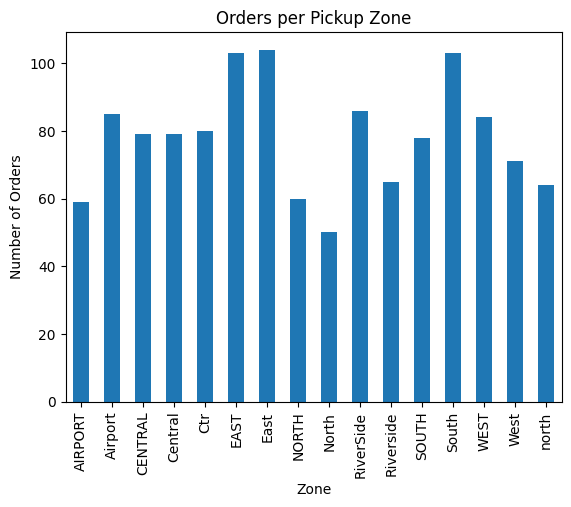

In [8]:
zone_orders = orders.groupby("pickup_zone")["order_id"].count()

print(zone_orders)

plt.figure()

zone_orders.plot(kind="bar")

plt.title("Orders per Pickup Zone")

plt.xlabel("Zone")

plt.ylabel("Number of Orders")

plt.show()

# ANALYSIS 3 — Driver performance score

Purpose:
measure workforce effectiveness

count    163.000000
mean     311.300785
std       53.733723
min      165.600000
25%      273.577500
50%      319.000000
75%      348.820000
max      482.500000
Name: performance_score, dtype: float64


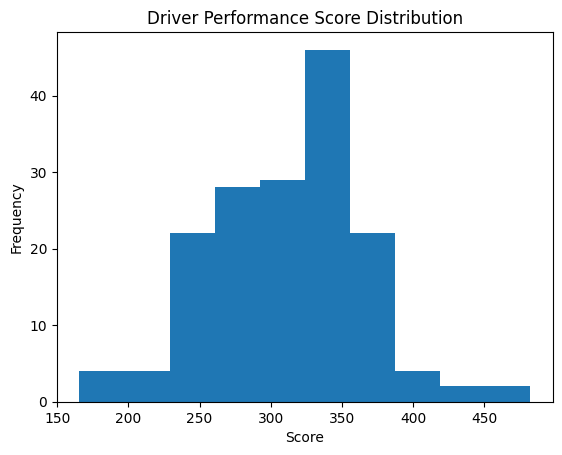

In [10]:
drivers["performance_score"] = (
    drivers["driver_rating"] * drivers["training_score"]
)

print(drivers["performance_score"].describe())

plt.figure()

drivers["performance_score"].plot(kind="hist")

plt.title("Driver Performance Score Distribution")

plt.xlabel("Score")

plt.ylabel("Frequency")

plt.show()

# ANALYSIS 4 — Vehicle maintenance risk

Purpose:
identify fleet reliability issues

Vehicles with low battery health
    vehicle_id  battery_health_pct
1         V002                67.9
4         V005                58.6
6         V007                68.6
8         V009                68.8
9         V010                50.7
11        V012                56.2
12        V013                68.3
15        V016                63.5
24        V025                42.0
36        V037                56.6
38        V039                69.5
48        V049                55.9
60        V061                60.3
63        V064                67.3
66        V067                57.3
69        V070                62.6
73        V074                62.4
75        V076                65.8
76        V077                67.6
83        V084                47.6
86        V087                49.7
90        V091                58.5
92        V093                69.2
93        V094                65.9
97        V098                69.7
98        V099                65.8
99        V100        

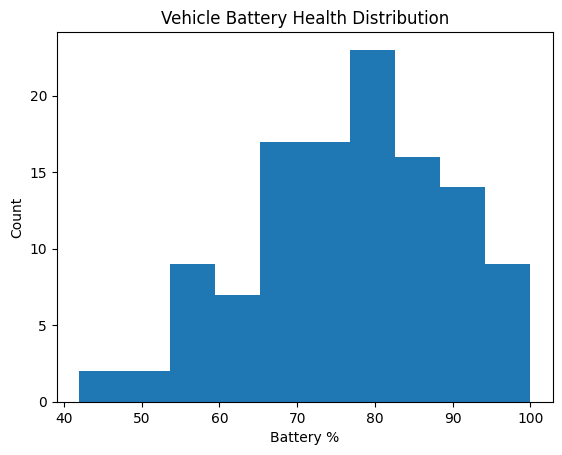

In [11]:
risk_vehicles = vehicles[
    vehicles["battery_health_pct"] < 70
]

print("Vehicles with low battery health")

print(risk_vehicles[["vehicle_id","battery_health_pct"]])

plt.figure()

vehicles["battery_health_pct"].plot(kind="hist")

plt.title("Vehicle Battery Health Distribution")

plt.xlabel("Battery %")

plt.ylabel("Count")

plt.show()

ANALYSIS 5 — Complaints per service type

Purpose:
link dissatisfaction to services

service_type
Business     39
Medical      37
Parcel       77
Passenger    84
Retail       83
Name: complaint_id, dtype: int64


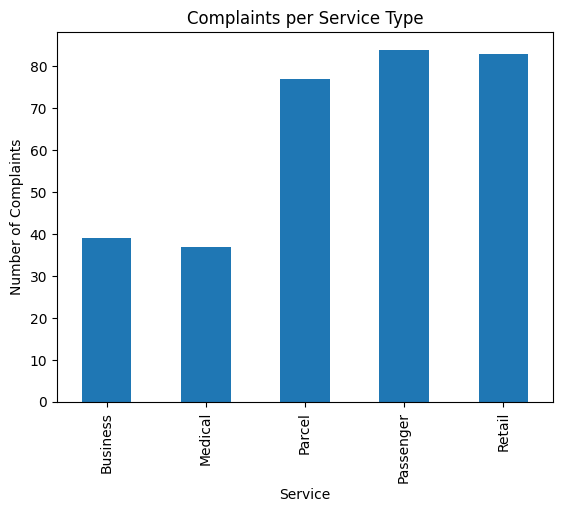

In [12]:
merged_data = pd.merge(
    orders,
    complaints,
    on="order_id"
)

complaint_service = merged_data.groupby(
    "service_type"
)["complaint_id"].count()

print(complaint_service)

plt.figure()

complaint_service.plot(kind="bar")

plt.title("Complaints per Service Type")

plt.xlabel("Service")

plt.ylabel("Number of Complaints")

plt.show()

# ANALYSIS 6 — App usage intensity

Purpose:
understand platform interaction behaviour

event_type
cancel_attempt                  28
chat_escalated                  38
chat_opened                     88
delivery_instruction_update     75
eta_refresh                    105
payment_retry                   69
search_route                    99
track_order                    138
Name: event_id, dtype: int64


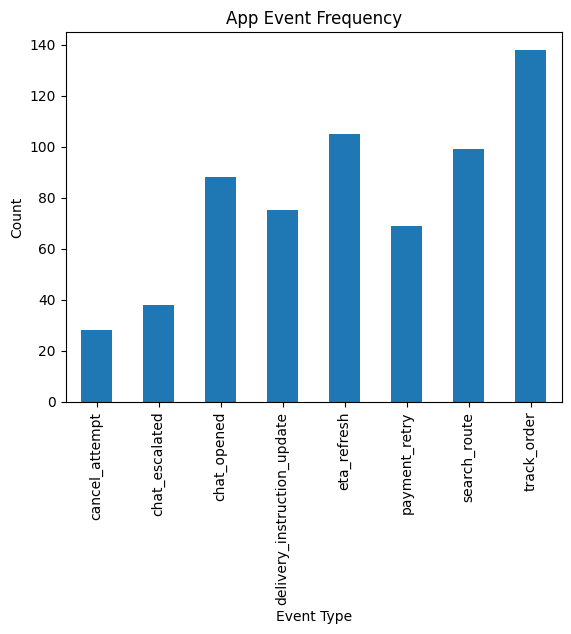

In [13]:
event_counts = app_events.groupby(
    "event_type"
)["event_id"].count()

print(event_counts)

plt.figure()

event_counts.plot(kind="bar")

plt.title("App Event Frequency")

plt.xlabel("Event Type")

plt.ylabel("Count")

plt.show()

# ANALYSIS 7 — Incident resolution time

Purpose:
identify operational inefficiencies

incident_type
AppSyncError        12.657143
BatteryAlert        11.708824
CustomerNoShow      13.888095
ProofMissing        10.767500
RouteDeviation      13.726829
SafetyNearMiss       9.669231
TemperatureIssue    12.917241
VehicleFault         9.150000
Name: resolved_hours, dtype: float64


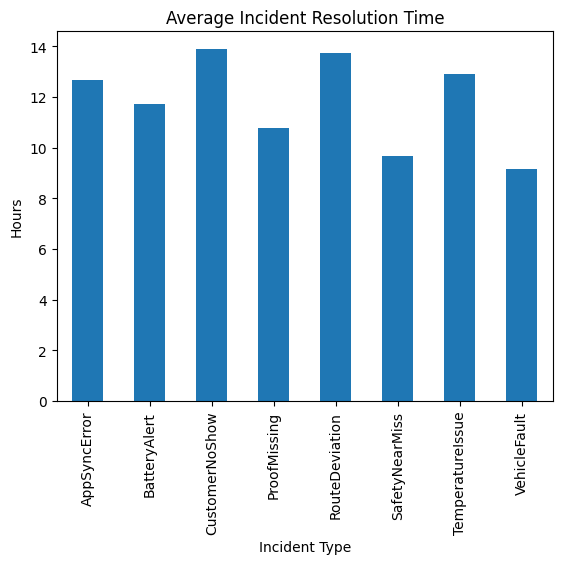

In [14]:
avg_resolution = incidents.groupby(
    "incident_type"
)["resolved_hours"].mean()

print(avg_resolution)

plt.figure()

avg_resolution.plot(kind="bar")

plt.title("Average Incident Resolution Time")

plt.xlabel("Incident Type")

plt.ylabel("Hours")

plt.show()

# ANALYSIS 8 — Order trend over time

Purpose:
identify demand patterns

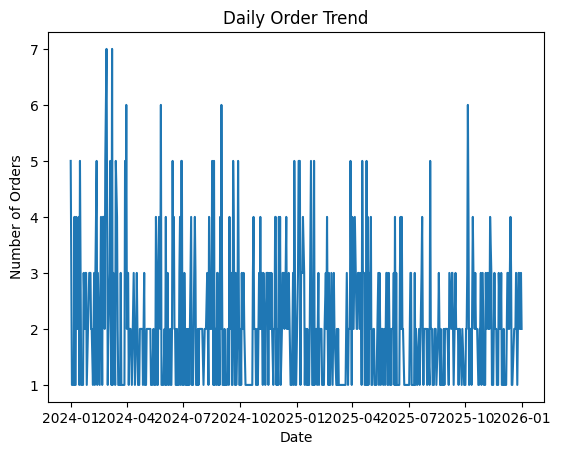

In [15]:
orders["date"] = orders["order_created_at"].dt.date

daily_orders = orders.groupby(
    "date"
)["order_id"].count()

plt.figure()

daily_orders.plot()

plt.title("Daily Order Trend")

plt.xlabel("Date")

plt.ylabel("Number of Orders")

plt.show()